In [1]:
import numpy as np
from scipy.stats import ks_2samp
from scipy import stats
from scipy import stats
import matplotlib.pyplot as plt
import h5py
import illustris_python as il
import sys
sys.path.append('../../py_files/')
#import weights
import control_sample as control
import BRAHMA_python as il_brahma
from tqdm import tqdm

import host_galaxy_enhancement_plots as hostplot
import utils 
from astropy.cosmology import Planck15
from astropy import units as u

In [2]:
import os
tex_path = '/apps/texlive/2023/bin/x86_64-linux/'
os.environ['PATH'] += os.pathsep + tex_path
import scienceplots
plt.style.use('science')

In [3]:
pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/' 
tng_pop_file_path = '/home/pranavsatheesh/host_galaxies/data/population_files/'

print("For TNG50:")
TNG_basepath = '/orange/lblecha/IllustrisTNG/Runs/TNG50-1/output'
TNG_50_pop = control.load_pop_file(TNG_basepath,tng_pop_file_path,[0,0,1000,1])
TNG_50_control = control.control_samples_TNG(TNG_50_pop)
TNG_color = '#d95f02'


brahma_basepath="/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/"
brahma_simName_array = ['SM5_TNG','SM5_LW10_TNG','SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG','SM5_LW10_LOWSPIN_TNG','SM5_LW10_LOWSPIN_RICH_TNG']
brahma_sim_colors = {
    brahma_simName_array[0]: '#bdc9e1', 
    brahma_simName_array[1]: '#67a9cf', 
    brahma_simName_array[2]: '#1c9099', 
    brahma_simName_array[3]: '#016c59',
    brahma_simName_array[4]: '#3690c0', 
    brahma_simName_array[5]: '#014636'  
}
brahma_sim_obj = {}
brahma_sim_zbins = {}
#brahma_sim_zbin_width = {}
for i,sim in enumerate(brahma_simName_array):
    print(sim)
    simPath = brahma_basepath + sim + '/'
    brahma_pop_Nstar10 = control.load_pop_file(simPath,pop_file_path,[0,0,10,1])
    brahma_control = control.control_sample_brahma(brahma_pop_Nstar10)
    brahma_sim_obj[sim] = brahma_control
    #brahma_sim_zbin_width,brahma_sim_zbins[sim] =hostplot.find_best_z_width(brahma_control.z_merging_pop,z_min=0,z_max=10,z_width_initial=0.2)
    brahma_sim_zbins[sim] = hostplot.find_adaptive_z_bins(brahma_control.z_merging_pop,z_min=0,z_max=10,zbin_width=0.2,min_N_values=10)
    


TNG_50_zbins = hostplot.find_adaptive_z_bins(TNG_50_control.z_merging_pop,z_min=0,z_max=10,zbin_width=0.3,min_N_values=50)
print('TNG50',TNG_50_zbins )
brahma_zbins = hostplot.find_brahma_adaptive_z_bins(brahma_sim_obj,brahma_simName_array,z_lower=0,z_max=10,zbin_width=0.1,min_N_values=10)
print('Brahma common zbins:',brahma_zbins)


sim_names = brahma_simName_array + ['TNG50']
sim_colors = {sim: brahma_sim_colors[sim] for sim in brahma_simName_array}
sim_colors['TNG50'] = TNG_color
sim_objs = brahma_sim_obj
sim_objs['TNG50'] = TNG_50_control
sim_zbins_list = brahma_sim_zbins
#sim_zbins_list = {sim: brahma_zbins for sim in brahma_simName_array}
sim_zbins_list['TNG50'] = TNG_50_zbins

For TNG50:


processing each merger redshifts for controls: 100%|██████████| 83/83 [00:03<00:00, 27.16it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:383: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop


Number of available mergers in this population is 504
Number of cases where a close enough match is not found within the acceptable tolerance: 14
SM5_TNG


processing each merger redshifts for controls: 100%|██████████| 16/16 [00:00<00:00, 16.06it/s]
/home/pranavsatheesh/host_galaxies/notebooks/paper_results/../../py_files/control_sample.py:620: RuntimeWarning: invalid value encountered in divide
  self.sBHAR_control_pop = self.Mdot_control_pop/self.MBH_control_pop


Number of cases where a close enough match is not found within the acceptable tolerance: 110
number of processable mergers with valid controls:
664
[22, 20, 37, 53, 95, 97, 138, 97, 48, 33, 17]
SM5_LW10_TNG


...

Number of cases where a close enough match is not found within the acceptable tolerance: 328
number of processable mergers with valid controls:
795
[37, 40, 45, 91, 100, 105, 149, 120, 69, 21, 14]
SM5_LW10_LOWSPIN_TNG


processing each merger redshifts for controls: 100%|██████████| 17/17 [00:00<00:00, 28.69it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 80
number of processable mergers with valid controls:
405
[21, 16, 13, 29, 41, 44, 91, 59, 35, 26, 19, 11]
SM5_LW10_LOWSPIN_RICH_TNG


processing each merger redshifts for controls: 100%|██████████| 18/18 [00:00<00:00, 94.52it/s]


Number of cases where a close enough match is not found within the acceptable tolerance: 49
number of processable mergers with valid controls:
127
[12, 24, 14, 25, 12, 17, 11, 10]
[55, 57, 54, 63, 65, 57, 70, 50]
TNG50 [0.  0.3 0.6 0.9 1.3 1.7 2.1 2.6 3.8]
Brahma common zbins: [0.  0.4 1.  1.6 2.2 3.1 4.1 5.1 8.1]


In [4]:
t_delays = utils.find_merger_time_delays(sim_objs,sim_names)

In [5]:
# Find unique redshifts in the range 4 < z < 5 for SM5_DFD_3_TNG
highz_mask_for_sm5_dfd_3 = (sim_objs['SM5_DFD_3_TNG'].z_merging_pop >= 4) & (sim_objs['SM5_DFD_3_TNG'].z_merging_pop < 5)
unique_z = np.unique(sim_objs['SM5_DFD_3_TNG'].z_merging_pop[highz_mask_for_sm5_dfd_3])

print(f"Unique redshifts in range (4 < z < 5) for SM5_DFD_3_TNG:")
print(f"Number of unique z values: {len(unique_z)}")
print(f"Min z: {unique_z.min():.4f}")
print(f"Max z: {unique_z.max():.4f}")
print(f"\nAll unique z values:")
print(unique_z)

# Also show counts per redshift
z_counts = np.unique(sim_objs['SM5_DFD_3_TNG'].z_merging_pop[highz_mask_for_sm5_dfd_3], return_counts=True)
print(f"\nRedshift bins with galaxy counts:")
for z, count in zip(z_counts[0], z_counts[1]):
    print(f"  z = {z:.4f}: {count} galaxies")

Unique redshifts in range (4 < z < 5) for SM5_DFD_3_TNG:
Number of unique z values: 2
Min z: 4.0079
Max z: 4.9959

All unique z values:
[4.00794511 4.99593347]

Redshift bins with galaxy counts:
  z = 4.0079: 59 galaxies
  z = 4.9959: 36 galaxies


In [6]:
z4_mask = (sim_objs['SM5_DFD_3_TNG'].z_merging_pop == unique_z[0])
z5_mask = (sim_objs['SM5_DFD_3_TNG'].z_merging_pop == unique_z[1])

num_z4_galaxies = np.sum(z4_mask)
print(f"\nNumber of galaxies at z={unique_z[0]:.4f} in SM5_DFD_3_TNG: {num_z4_galaxies}")

num_z5_galaxies = np.sum(z5_mask)
print(f"\nNumber of galaxies at z={unique_z[1]:.4f} in SM5_DFD_3_TNG: {num_z5_galaxies}")



Number of galaxies at z=4.0079 in SM5_DFD_3_TNG: 59

Number of galaxies at z=4.9959 in SM5_DFD_3_TNG: 36


Text(0.5, 1.0, 'SM5_DFD_3_TNG [z$\\sim$5]')

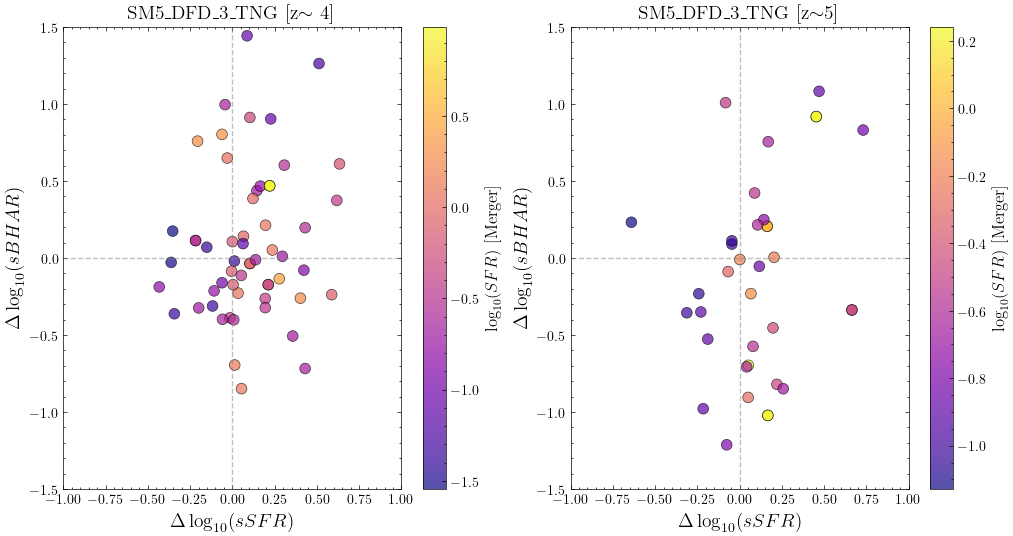

In [7]:
fig,axes = plt.subplots(1,2,figsize=(12,6))



sSFR_merger = sim_objs['SM5_DFD_3_TNG'].sSFR_merging_pop[z4_mask]
sSFR_control = sim_objs['SM5_DFD_3_TNG'].sSFR_control_pop[z4_mask]
sBHAR_merger = sim_objs['SM5_DFD_3_TNG'].sBHAR_merging_pop[z4_mask]
sBHAR_control = sim_objs['SM5_DFD_3_TNG'].sBHAR_control_pop[z4_mask]

# Filter valid data (positive values, no NaNs)
valid_mask = (sSFR_merger > 0) & (sSFR_control > 0) & (sBHAR_merger > 0) & (sBHAR_control > 0) & \
             (~np.isnan(sSFR_merger)) & (~np.isnan(sSFR_control)) & (~np.isnan(sBHAR_merger)) & (~np.isnan(sBHAR_control))
sSFR_enhancement = np.log10(sSFR_merger[valid_mask] / sSFR_control[valid_mask])
sBHAR_enhancement = np.log10(sBHAR_merger[valid_mask] / sBHAR_control[valid_mask])

SFR_merger = sim_objs['SM5_DFD_3_TNG'].SFR_merging_pop[z4_mask][valid_mask]
scatter = axes[0].scatter(sSFR_enhancement,sBHAR_enhancement, c=np.log10(SFR_merger), 
                     alpha=0.7, s=60, edgecolors='k', linewidth=0.5, cmap='plasma')
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label(r'$\log_{10}(SFR)$ [Merger]', fontsize=12)
scatter.set_clim(np.min(np.log10(SFR_merger)), np.max(np.log10(SFR_merger)))
axes[0].set_xlabel(r'$\Delta \log_{10}(sSFR)$', fontsize=14)
axes[0].set_ylabel(r'$\Delta \log_{10}(sBHAR)$', fontsize=14)
axes[0].axhline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
axes[0].axvline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
axes[0].set_xlim(-1,1)
axes[0].set_ylim(-1.5,1.5)
axes[0].set_title(f'SM5_DFD_3_TNG [z$\sim${int(unique_z[0]):2d}]', fontsize=14)


sSFR_merger = sim_objs['SM5_DFD_3_TNG'].sSFR_merging_pop[z5_mask]
sSFR_control = sim_objs['SM5_DFD_3_TNG'].sSFR_control_pop[z5_mask]
sBHAR_merger = sim_objs['SM5_DFD_3_TNG'].sBHAR_merging_pop[z5_mask]
sBHAR_control = sim_objs['SM5_DFD_3_TNG'].sBHAR_control_pop[z5_mask]

# Filter valid data (positive values, no NaNs)
valid_mask = (sSFR_merger > 0) & (sSFR_control > 0) & (sBHAR_merger > 0) & (sBHAR_control > 0) & \
             (~np.isnan(sSFR_merger)) & (~np.isnan(sSFR_control)) & (~np.isnan(sBHAR_merger)) & (~np.isnan(sBHAR_control))
sSFR_enhancement = np.log10(sSFR_merger[valid_mask] / sSFR_control[valid_mask])
sBHAR_enhancement = np.log10(sBHAR_merger[valid_mask] / sBHAR_control[valid_mask])
SFR_merger = sim_objs['SM5_DFD_3_TNG'].SFR_merging_pop[z5_mask][valid_mask]
scatter = axes[1].scatter(sSFR_enhancement,sBHAR_enhancement, c=np.log10(SFR_merger),
                        alpha=0.7, s=60, edgecolors='k', linewidth=0.5, cmap='plasma')
cbar = plt.colorbar(scatter, ax=axes[1])
cbar.set_label(r'$\log_{10}(SFR)$ [Merger]', fontsize=12)
scatter.set_clim(np.min(np.log10(SFR_merger)), np.max(np.log10(SFR_merger)))
axes[1].set_xlabel(r'$\Delta \log_{10}(sSFR)$', fontsize=14)
axes[1].set_ylabel(r'$\Delta \log_{10}(sBHAR)$', fontsize=14)
axes[1].axhline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
axes[1].axvline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
axes[1].set_xlim(-1,1)
axes[1].set_ylim(-1.5,1.5)
axes[1].set_title(f'SM5_DFD_3_TNG [z$\sim$5]', fontsize=14)


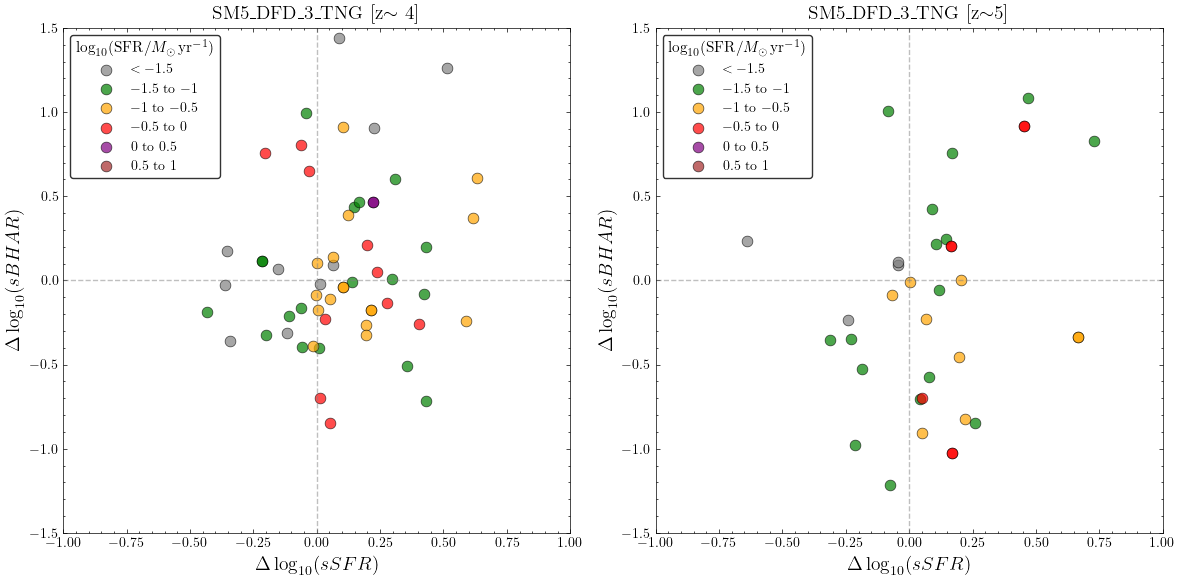

In [13]:
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Define SFR bins (in log10 space) and colors
sfr_bins = [-np.inf, -1,-0.5,0,0.5,1,np.inf]  # e.g., <1, 1-3, 3-10, 10-30, >30 Msun/yr
sfr_colors = ['grey', 'green', 'orange', 'red', 'purple', 'brown']
sfr_labels = [
    r'$<-1.5$', r'$-1.5$ to $-1$', r'$-1$ to $-0.5$', r'$-0.5$ to $0$', r'$0$ to $0.5$', r'$0.5$ to $1$', r'$>1$'
]
for i, (mask, ax, zlabel) in enumerate(zip([z4_mask, z5_mask], axes, [f'z$\sim${int(unique_z[0]):2d}', 'z$\sim$5'])):
    sSFR_merger = sim_objs['SM5_DFD_3_TNG'].sSFR_merging_pop[mask]
    sSFR_control = sim_objs['SM5_DFD_3_TNG'].sSFR_control_pop[mask]
    sBHAR_merger = sim_objs['SM5_DFD_3_TNG'].sBHAR_merging_pop[mask]
    sBHAR_control = sim_objs['SM5_DFD_3_TNG'].sBHAR_control_pop[mask]
    SFR_merger = sim_objs['SM5_DFD_3_TNG'].SFR_merging_pop[mask]

    valid_mask = (sSFR_merger > 0) & (sSFR_control > 0) & (sBHAR_merger > 0) & (sBHAR_control > 0) & \
                 (~np.isnan(sSFR_merger)) & (~np.isnan(sSFR_control)) & (~np.isnan(sBHAR_merger)) & (~np.isnan(sBHAR_control))
    sSFR_enhancement = np.log10(sSFR_merger[valid_mask] / sSFR_control[valid_mask])
    sBHAR_enhancement = np.log10(sBHAR_merger[valid_mask] / sBHAR_control[valid_mask])
    log_SFR_merger = np.log10(SFR_merger[valid_mask])

    # Plot each SFR bin with its color
    for j in range(len(sfr_bins) - 1):
        bin_mask = (log_SFR_merger > sfr_bins[j]) & (log_SFR_merger <= sfr_bins[j+1])
        ax.scatter(
            sSFR_enhancement[bin_mask], sBHAR_enhancement[bin_mask],
            color=sfr_colors[j], alpha=0.7, s=60, edgecolors='k', linewidth=0.5, label=sfr_labels[j]
        )

    ax.set_xlabel(r'$\Delta \log_{10}(sSFR)$', fontsize=14)
    ax.set_ylabel(r'$\Delta \log_{10}(sBHAR)$', fontsize=14)
    ax.axhline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
    ax.axvline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
    ax.set_xlim(-1, 1)
    ax.set_ylim(-1.5, 1.5)
    ax.set_title(f'SM5_DFD_3_TNG [{zlabel}]', fontsize=14)
    ax.legend(title=r'$\log_{10}(\mathrm{SFR}/M_\odot\,\mathrm{yr}^{-1})$', fontsize=10, title_fontsize=11, loc='best', frameon=True, edgecolor='black')

plt.tight_layout()

Text(0.5, 1.0, 'SM5_DFD_3_TNG [z$\\sim$5]')

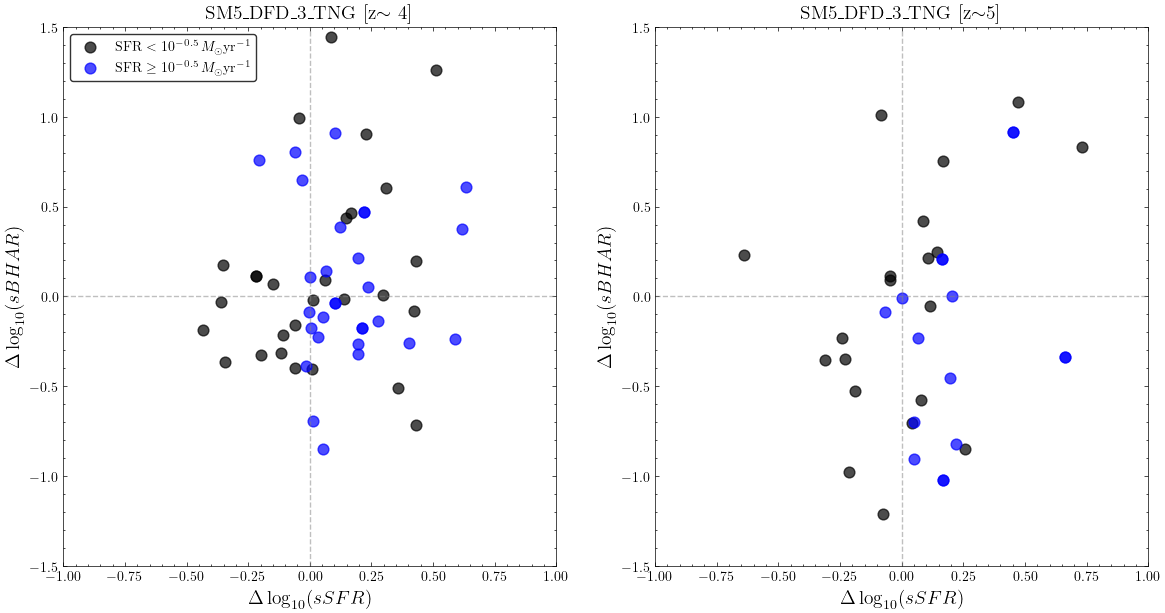

In [8]:
fig,axes = plt.subplots(1,2,figsize=(14,7))

sSFR_merger = sim_objs['SM5_DFD_3_TNG'].sSFR_merging_pop[z4_mask]
sSFR_control = sim_objs['SM5_DFD_3_TNG'].sSFR_control_pop[z4_mask]
sBHAR_merger = sim_objs['SM5_DFD_3_TNG'].sBHAR_merging_pop[z4_mask]
sBHAR_control = sim_objs['SM5_DFD_3_TNG'].sBHAR_control_pop[z4_mask]

# Filter valid data (positive values, no NaNs)
valid_mask = (sSFR_merger > 0) & (sSFR_control > 0) & (sBHAR_merger > 0) & (sBHAR_control > 0) & \
             (~np.isnan(sSFR_merger)) & (~np.isnan(sSFR_control)) & (~np.isnan(sBHAR_merger)) & (~np.isnan(sBHAR_control))
sSFR_enhancement = np.log10(sSFR_merger[valid_mask] / sSFR_control[valid_mask])
sBHAR_enhancement = np.log10(sBHAR_merger[valid_mask] / sBHAR_control[valid_mask])

log_SFR_merger = np.log10(sim_objs['SM5_DFD_3_TNG'].SFR_merging_pop[z4_mask][valid_mask])
high_SF_galaxy_mask = log_SFR_merger >= -0.5 # Example threshold for high SFR (SFR > 10 M_sun/yr)
low_SF_galaxy_mask = log_SFR_merger < -0.5


scatter_low_SF = axes[0].scatter(sSFR_enhancement[low_SF_galaxy_mask], sBHAR_enhancement[low_SF_galaxy_mask], 
                        color="black",alpha=0.7, s=60, edgecolors='k',  label=r'SFR $< 10^{-0.5}\, M_\odot \mathrm{yr}^{-1}$')
scatter_high_SF = axes[0].scatter(sSFR_enhancement[high_SF_galaxy_mask], sBHAR_enhancement[high_SF_galaxy_mask], 
                            color="blue",alpha=0.7, s=60, label=r'SFR $\geq 10^{-0.5} \, M_\odot \mathrm{yr}^{-1}$')      
axes[0].set_xlabel(r'$\Delta \log_{10}(sSFR)$', fontsize=14)
axes[0].set_ylabel(r'$\Delta \log_{10}(sBHAR)$', fontsize=14)
axes[0].axhline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
axes[0].axvline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
axes[0].set_xlim(-1,1)
axes[0].set_ylim(-1.5,1.5)
axes[0].legend(fontsize=10, loc='best',frameon=True, edgecolor='black')
axes[0].set_title(f'SM5_DFD_3_TNG [z$\sim${int(unique_z[0]):2d}]', fontsize=14)


sSFR_merger = sim_objs['SM5_DFD_3_TNG'].sSFR_merging_pop[z5_mask]
sSFR_control = sim_objs['SM5_DFD_3_TNG'].sSFR_control_pop[z5_mask]
sBHAR_merger = sim_objs['SM5_DFD_3_TNG'].sBHAR_merging_pop[z5_mask]
sBHAR_control = sim_objs['SM5_DFD_3_TNG'].sBHAR_control_pop[z5_mask]


valid_mask = (sSFR_merger > 0) & (sSFR_control > 0) & (sBHAR_merger > 0) & (sBHAR_control > 0) & \
             (~np.isnan(sSFR_merger)) & (~np.isnan(sSFR_control)) & (~np.isnan(sBHAR_merger)) & (~np.isnan(sBHAR_control))
sSFR_enhancement = np.log10(sSFR_merger[valid_mask] / sSFR_control[valid_mask])
sBHAR_enhancement = np.log10(sBHAR_merger[valid_mask] / sBHAR_control[valid_mask])

log_SFR_merger = np.log10(sim_objs['SM5_DFD_3_TNG'].SFR_merging_pop[z5_mask][valid_mask])
high_SF_galaxy_mask = log_SFR_merger >= -0.5 # Example threshold for high SFR (SFR > 10 M_sun/yr)
low_SF_galaxy_mask = log_SFR_merger < -0.5


scatter_low_SF = axes[1].scatter(sSFR_enhancement[low_SF_galaxy_mask], sBHAR_enhancement[low_SF_galaxy_mask], 
                        color="black",alpha=0.7, s=60, edgecolors='k',  label=r'sSFR $< 10^{-8.5}\, \mathrm{yr}^{-1}$')
scatter_high_SF = axes[1].scatter(sSFR_enhancement[high_SF_galaxy_mask], sBHAR_enhancement[high_SF_galaxy_mask], 
                            color="blue",alpha=0.7, s=60, label=r'sSFR $\geq 10^{-8.5} \, \mathrm{yr}^{-1}$')      


axes[1].set_xlabel(r'$\Delta \log_{10}(sSFR)$', fontsize=14)
axes[1].set_ylabel(r'$\Delta \log_{10}(sBHAR)$', fontsize=14)
axes[1].axhline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
axes[1].axvline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
axes[1].set_xlim(-1,1)
axes[1].set_ylim(-1.5,1.5)
axes[1].set_title(f'SM5_DFD_3_TNG [z$\sim$5]', fontsize=14)


Unique redshifts in range (0 < z < 1) for TNG50:
Number of unique z values: 49
Min z: 0.0000
Max z: 0.9973


/tmp/ipykernel_2189364/3102563689.py:42: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=12, loc='best')


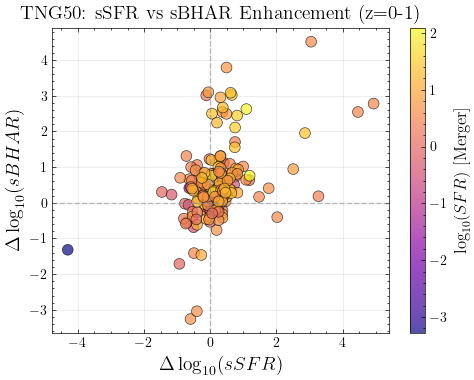

In [141]:
# Find unique redshifts for TNG50
lowz_mask_for_tng50 = (sim_objs['TNG50'].z_merging_pop >= 0) & (sim_objs['TNG50'].z_merging_pop < 1)
unique_z_tng50 = np.unique(sim_objs['TNG50'].z_merging_pop[lowz_mask_for_tng50])

print(f"Unique redshifts in range (0 < z < 1) for TNG50:")
print(f"Number of unique z values: {len(unique_z_tng50)}")
print(f"Min z: {unique_z_tng50.min():.4f}")
print(f"Max z: {unique_z_tng50.max():.4f}")

# Find correlation between sSFR and sBHAR enhancement at low-z for TNG50
sSFR_merger_tng = sim_objs['TNG50'].sSFR_merging_pop[lowz_mask_for_tng50]
sSFR_control_tng = sim_objs['TNG50'].sSFR_control_pop[lowz_mask_for_tng50]
sBHAR_merger_tng = sim_objs['TNG50'].sBHAR_merging_pop[lowz_mask_for_tng50]
sBHAR_control_tng = sim_objs['TNG50'].sBHAR_control_pop[lowz_mask_for_tng50]

# Filter valid data
valid_mask_tng = (sSFR_merger_tng > 0) & (sSFR_control_tng > 0) & (sBHAR_merger_tng > 0) & (sBHAR_control_tng > 0) & \
                 (~np.isnan(sSFR_merger_tng)) & (~np.isnan(sSFR_control_tng)) & (~np.isnan(sBHAR_merger_tng)) & (~np.isnan(sBHAR_control_tng))

sSFR_enhancement_tng = np.log10(sSFR_merger_tng[valid_mask_tng] / sSFR_control_tng[valid_mask_tng])
sBHAR_enhancement_tng = np.log10(sBHAR_merger_tng[valid_mask_tng] / sBHAR_control_tng[valid_mask_tng])

fig, ax = plt.subplots(figsize=(5,4))

# Get SFR values for color coding
SFR_merger_tng = sim_objs['TNG50'].SFR_merging_pop[lowz_mask_for_tng50][valid_mask_tng]

# Create scatter plot with SFR as color
scatter = ax.scatter(sSFR_enhancement_tng, sBHAR_enhancement_tng, c=np.log10(SFR_merger_tng), 
                     alpha=0.7, s=60, edgecolors='k', linewidth=0.5, cmap='plasma')

# Add colorbar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label(r'$\log_{10}(SFR)$ [Merger]', fontsize=12)

ax.set_xlabel(r'$\Delta \log_{10}(sSFR)$', fontsize=14)
ax.set_ylabel(r'$\Delta \log_{10}(sBHAR)$', fontsize=14)
ax.set_title(f'TNG50: sSFR vs sBHAR Enhancement (z=0-1)', fontsize=14, fontweight='bold')
ax.axhline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
ax.axvline(0, ls='--', color='grey', alpha=0.5, linewidth=1)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12, loc='best')
fig.tight_layout()
plt.show()